In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

pd.set_option('display.max_columns', 35)
pd.set_option('display.max_rows', 20)


In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/tharsthanu/ibm-hr-analytics/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nFirst 5 rows:")
df.head()


Dataset Shape: (1470, 35)
Rows: 1470, Columns: 35

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
# Check data types and missing values
print("Data Types:")
print(df.dtypes)

print("\nMissing Values Check:")
print(df.isnull().sum())
print("\n")
print("Duplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
df.describe()

Data Types:
Age                         int64
Attrition                  object
BusinessTravel             object
DailyRate                   int64
Department                 object
                            ...  
WorkLifeBalance             int64
YearsAtCompany              int64
YearsInCurrentRole          int64
YearsSinceLastPromotion     int64
YearsWithCurrManager        int64
Length: 35, dtype: object

Missing Values Check:
Age                        0
Attrition                  0
BusinessTravel             0
DailyRate                  0
Department                 0
                          ..
WorkLifeBalance            0
YearsAtCompany             0
YearsInCurrentRole         0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
Length: 35, dtype: int64


Duplicate Rows: 0

Statistical Summary:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


UNDERSTAND CURRENT TURNOVER RATES

Overall Attrition Rate :
Total Employees: 1,470
Employees who Left (Yes): 237 (16.12%)
Employees who Stayed (No): 1233 (83.88%)


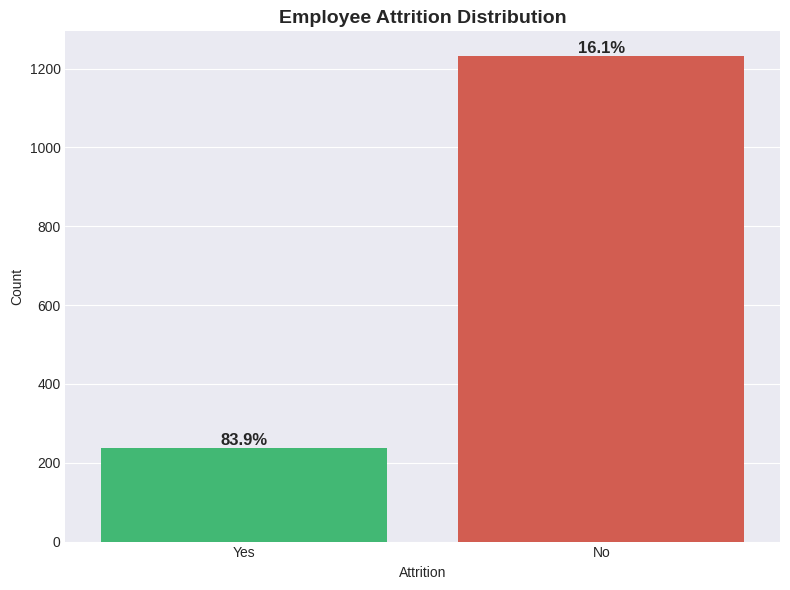

In [4]:
# Overall Attrition Rate
print("UNDERSTAND CURRENT TURNOVER RATES")
print("\nOverall Attrition Rate :")

attrition_counts = df['Attrition'].value_counts()
attrition_percent = df['Attrition'].value_counts(normalize=True) * 100

print(f"Total Employees: {len(df):,}")
print(f"Employees who Left (Yes): {attrition_counts['Yes']} ({attrition_percent['Yes']:.2f}%)")
print(f"Employees who Stayed (No): {attrition_counts['No']} ({attrition_percent['No']:.2f}%)")

# Visualization
plt.figure(figsize=(8, 6))
colors = ['#2ecc71', '#e74c3c']
ax = sns.countplot(data=df, x='Attrition', palette=colors)
for i, p in enumerate(ax.patches):
    ax.annotate(f'{attrition_percent.iloc[i]:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.title('Employee Attrition Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Attrition by Age Group 
AgeGroup
18-25    34.782609
26-35    19.141914
56+      17.021277
46-55    11.504425
36-45     9.188034
Name: Yes, dtype: float64


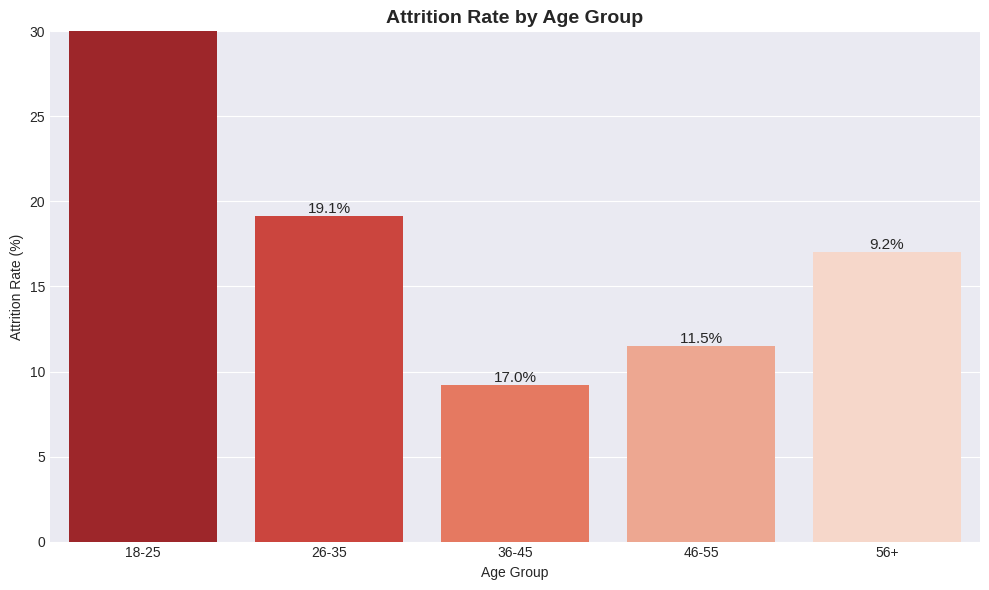

In [5]:
# Attrition by Age Group
# Create age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65], 
                         labels=['18-25', '26-35', '36-45', '46-55', '56+'])

age_attrition = df.groupby('AgeGroup', observed=True)['Attrition'].value_counts(normalize=True).unstack() * 100
age_attrition['Yes'] = age_attrition['Yes'].fillna(0)
age_attrition = age_attrition.sort_values('Yes', ascending=False)

print("Attrition by Age Group ")
print(age_attrition['Yes'])

# Visualization
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=age_attrition.index, y=age_attrition['Yes'], palette='Reds_r')
for i, p in enumerate(ax.patches):
    ax.annotate(f'{age_attrition["Yes"].iloc[i]:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Attrition Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0, 30)
plt.tight_layout()
plt.show()

Attrition by Gender
Male Attrition Rate: 17.01%
Female Attrition Rate: 14.80%


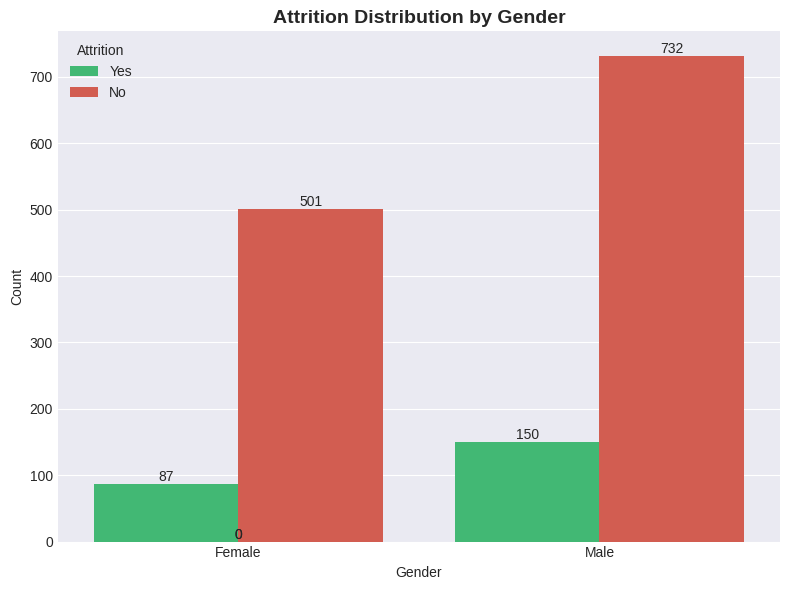

In [6]:
# Attrition by Gender
gender_attrition = df.groupby('Gender')['Attrition'].value_counts(normalize=True).unstack() * 100
gender_attrition['Yes'] = gender_attrition['Yes'].fillna(0)

print("Attrition by Gender")
print(f"Male Attrition Rate: {gender_attrition.loc['Male', 'Yes']:.2f}%")
print(f"Female Attrition Rate: {gender_attrition.loc['Female', 'Yes']:.2f}%")

# Visualization
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='Gender', hue='Attrition', palette=['#2ecc71', '#e74c3c'])
plt.title('Attrition Distribution by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Attrition')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

Attrition by Education Level
EducationLevel
Below College    18.235294
Bachelor         17.307692
College          15.602837
Master           14.572864
Doctor           10.416667
Name: Yes, dtype: float64


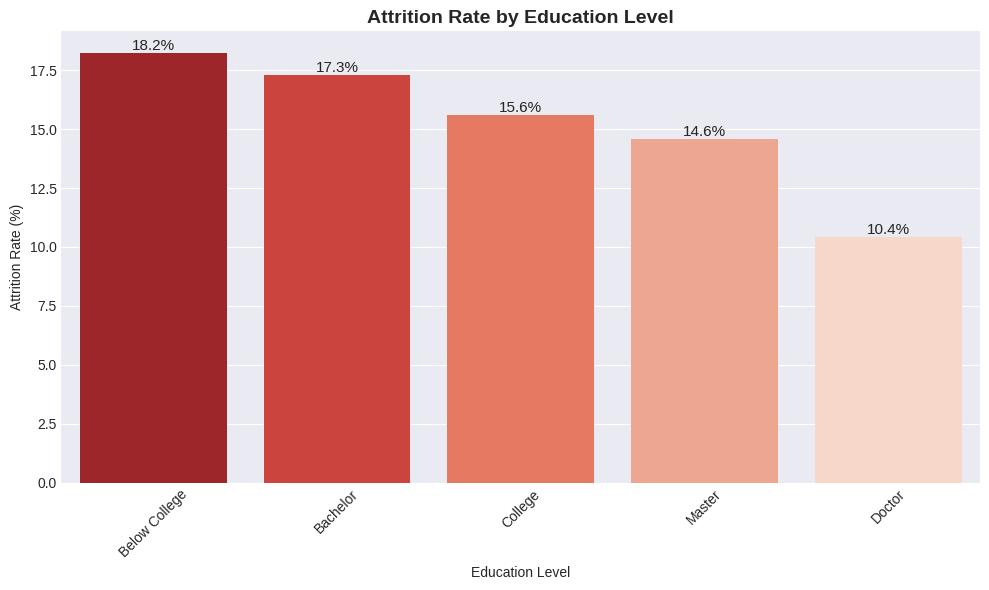

In [7]:
# Attrition by Education Level
# Education mapping
education_map = {1: 'Below College', 2: 'College', 3: 'Bachelor', 
                  4: 'Master', 5: 'Doctor'}
df['EducationLevel'] = df['Education'].map(education_map)

edu_attrition = df.groupby('EducationLevel', observed=True)['Attrition'].value_counts(normalize=True).unstack() * 100
edu_attrition['Yes'] = edu_attrition['Yes'].fillna(0)
edu_attrition = edu_attrition.sort_values('Yes', ascending=False)

print("Attrition by Education Level")
print(edu_attrition['Yes'])

# Visualization
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=edu_attrition.index, y=edu_attrition['Yes'], palette='Reds_r')
for i, p in enumerate(ax.patches):
    ax.annotate(f'{edu_attrition["Yes"].iloc[i]:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Attrition Rate by Education Level', fontsize=14, fontweight='bold')
plt.xlabel('Education Level')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Attrition by Department 
Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Yes, dtype: float64


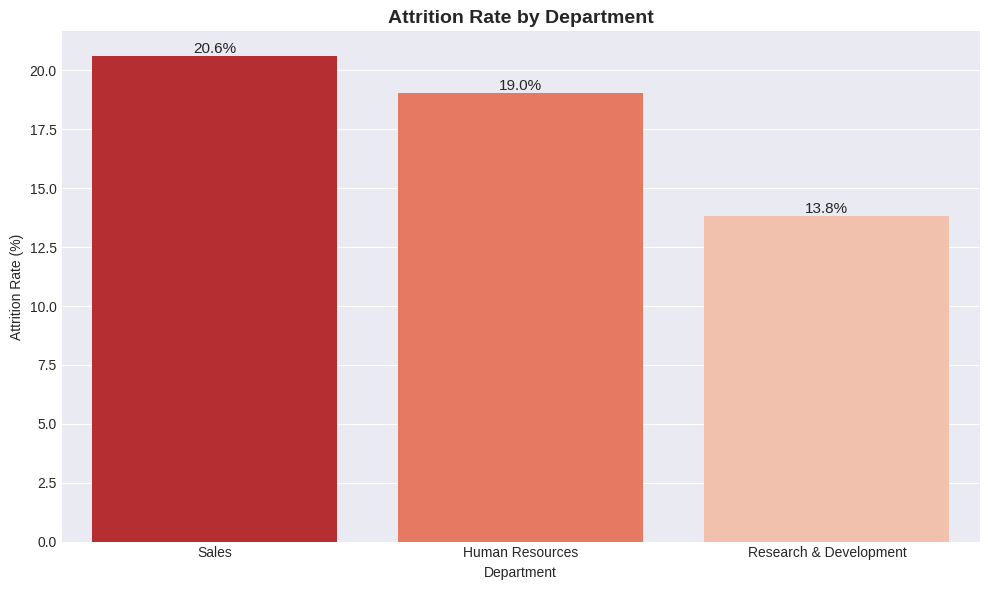

In [8]:
#Attrition by Department
dept_attrition = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
dept_attrition['Yes'] = dept_attrition['Yes'].fillna(0)
dept_attrition = dept_attrition.sort_values('Yes', ascending=False)

print("Attrition by Department ")
print(dept_attrition['Yes'])

# Visualization
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=dept_attrition.index, y=dept_attrition['Yes'], palette='Reds_r')
for i, p in enumerate(ax.patches):
    ax.annotate(f'{dept_attrition["Yes"].iloc[i]:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Attrition Rate by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

Attrition by Job Role (Highest to Lowest)
JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Yes, dtype: float64


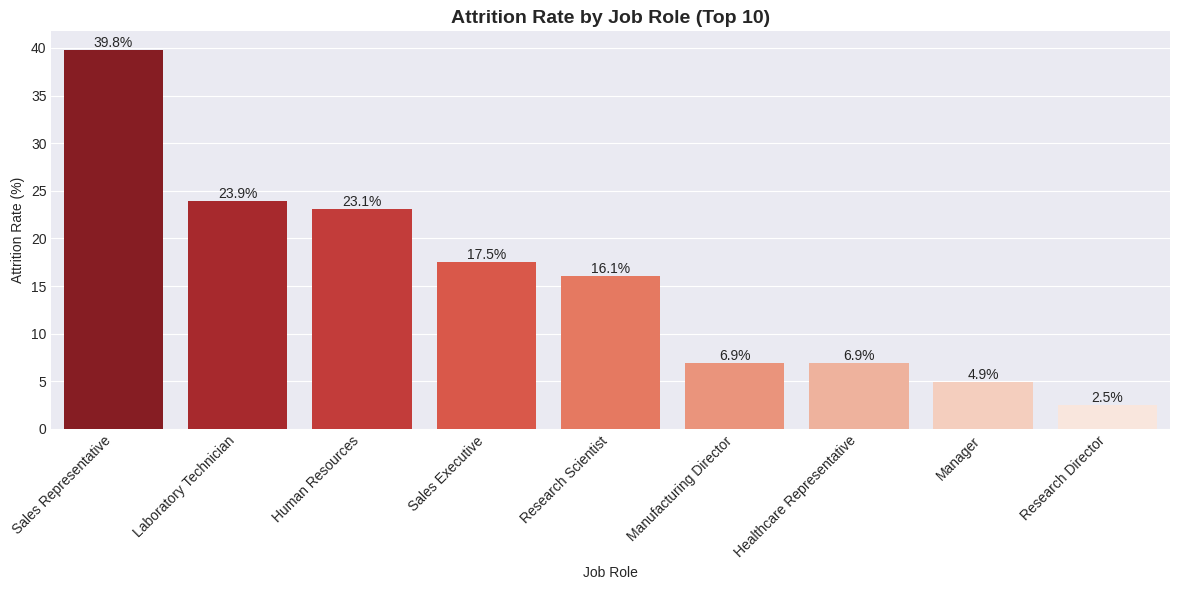

In [9]:
# Attrition by Job Role (Top 10)
job_attrition = df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack() * 100
job_attrition['Yes'] = job_attrition['Yes'].fillna(0)
job_attrition = job_attrition.sort_values('Yes', ascending=False)

print("Attrition by Job Role (Highest to Lowest)")
print(job_attrition['Yes'].head(10))

# Visualization
plt.figure(figsize=(12, 6))
top_roles = job_attrition.head(10)
ax = sns.barplot(x=top_roles.index, y=top_roles['Yes'], palette='Reds_r')
for i, p in enumerate(ax.patches):
    ax.annotate(f'{top_roles["Yes"].iloc[i]:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.title('Attrition Rate by Job Role (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

IDENTIFY KEY FACTORS INFLUENCING TURNOVER

Monthly Income Analysis
Monthly Income Statistics by Attrition Status:
                  mean  median          std
Attrition                                  
No         6832.739659  5204.0  4818.208001
Yes        4787.092827  3202.0  3640.210367

 Average Monthly Income by Education Level and Attrition
Attrition                No          Yes
EducationLevel                          
Bachelor        6882.919662  4770.242424
Below College   5926.129496  4360.161290
College         6586.058824  4282.545455
Doctor          8559.906977  5850.200000
Master          7087.814706  5335.155172


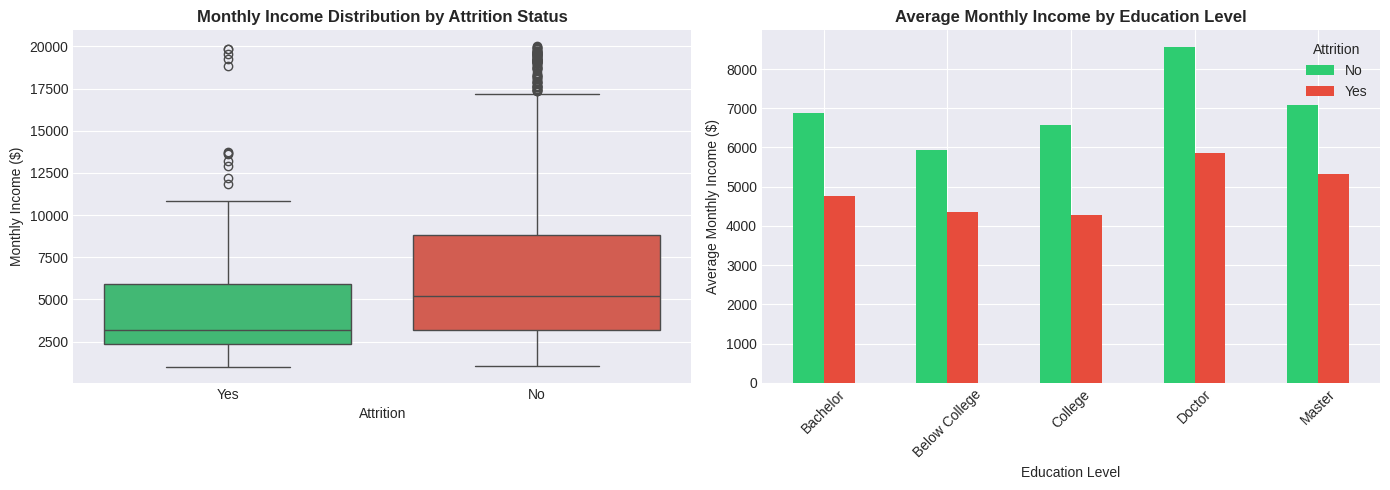

In [10]:
# Identify Key Factors Influencing Turnover
print("IDENTIFY KEY FACTORS INFLUENCING TURNOVER")
print("\nMonthly Income Analysis")

# Compare monthly income by attrition
income_stats = df.groupby('Attrition')['MonthlyIncome'].agg(['mean', 'median', 'std'])
print("Monthly Income Statistics by Attrition Status:")
print(income_stats)

# Monthly Income by Education and Attrition
income_edu_attrition = df.groupby(['EducationLevel', 'Attrition'], observed=True)['MonthlyIncome'].mean().unstack()
print("\n Average Monthly Income by Education Level and Attrition")
print(income_edu_attrition)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Boxplot of Monthly Income by Attrition
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Monthly Income Distribution by Attrition Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Monthly Income ($)')

# Plot 2: Income by Education and Attrition
income_edu_pivot = df.pivot_table(index='EducationLevel', columns='Attrition', 
                                   values='MonthlyIncome', aggfunc='mean', observed=True)
income_edu_pivot.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Average Monthly Income by Education Level', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Education Level')
axes[1].set_ylabel('Average Monthly Income ($)')
axes[1].legend(title='Attrition')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Job Satisfaction Impact on Attrition
JobSatisfactionLevel
High         16.515837
Low          22.837370
Medium       16.428571
Very High    11.328976
Name: Yes, dtype: float64


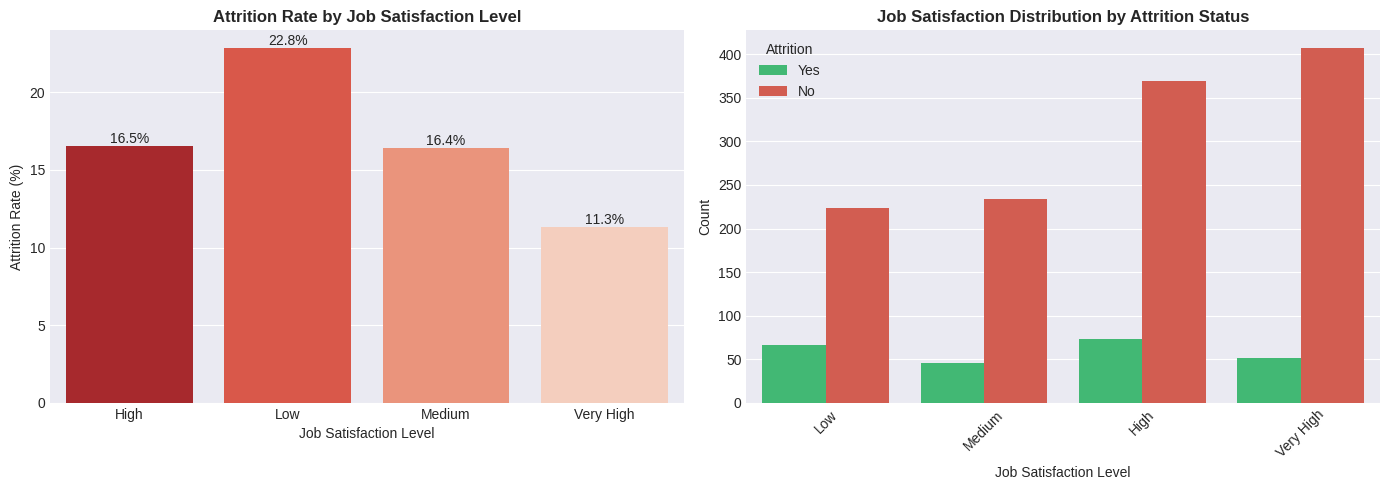

In [11]:
# Job Satisfaction Analysis
satisfaction_map = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}
df['JobSatisfactionLevel'] = df['JobSatisfaction'].map(satisfaction_map)

sat_attrition = df.groupby('JobSatisfactionLevel', observed=True)['Attrition'].value_counts(normalize=True).unstack() * 100
sat_attrition['Yes'] = sat_attrition['Yes'].fillna(0)

print("Job Satisfaction Impact on Attrition")
print(sat_attrition['Yes'])

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Attrition rate by job satisfaction
ax = sns.barplot(x=sat_attrition.index, y=sat_attrition['Yes'], ax=axes[0], palette='Reds_r')
for i, p in enumerate(ax.patches):
    ax.annotate(f'{sat_attrition["Yes"].iloc[i]:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
axes[0].set_title('Attrition Rate by Job Satisfaction Level', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Job Satisfaction Level')
axes[0].set_ylabel('Attrition Rate (%)')

# Plot 2: Distribution of satisfaction levels between groups
sns.countplot(data=df, x='JobSatisfactionLevel', hue='Attrition', ax=axes[1], 
              palette=['#2ecc71', '#e74c3c'], order=['Low', 'Medium', 'High', 'Very High'])
axes[1].set_title('Job Satisfaction Distribution by Attrition Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Job Satisfaction Level')
axes[1].set_ylabel('Count')
axes[1].legend(title='Attrition')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Work-Life Balance Impact on Attrition
WorkLifeBalanceLevel
Bad       31.250000
Best      17.647059
Better    14.221725
Good      16.860465
Name: Yes, dtype: float64


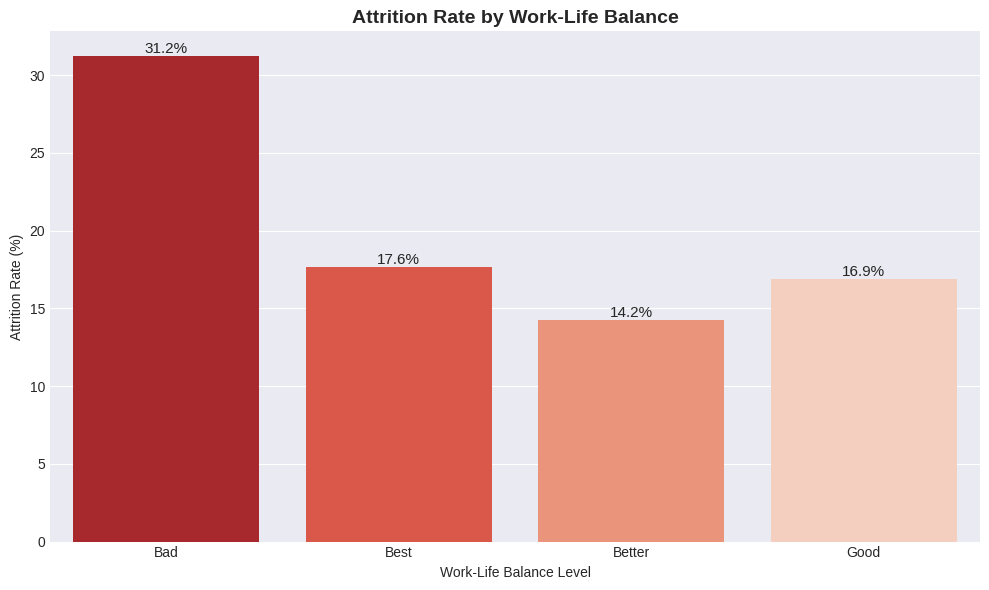

In [12]:
# Work-Life Balance Analysis
wlb_map = {1: 'Bad', 2: 'Good', 3: 'Better', 4: 'Best'}
df['WorkLifeBalanceLevel'] = df['WorkLifeBalance'].map(wlb_map)

wlb_attrition = df.groupby('WorkLifeBalanceLevel', observed=True)['Attrition'].value_counts(normalize=True).unstack() * 100
wlb_attrition['Yes'] = wlb_attrition['Yes'].fillna(0)

print("Work-Life Balance Impact on Attrition")
print(wlb_attrition['Yes'])

# Visualization
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=wlb_attrition.index, y=wlb_attrition['Yes'], palette='Reds_r')
for i, p in enumerate(ax.patches):
    ax.annotate(f'{wlb_attrition["Yes"].iloc[i]:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Attrition Rate by Work-Life Balance', fontsize=14, fontweight='bold')
plt.xlabel('Work-Life Balance Level')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

Overtime Impact on Attrition
Employees with Overtime - Attrition Rate: 30.53%
Employees without Overtime - Attrition Rate: 10.44%


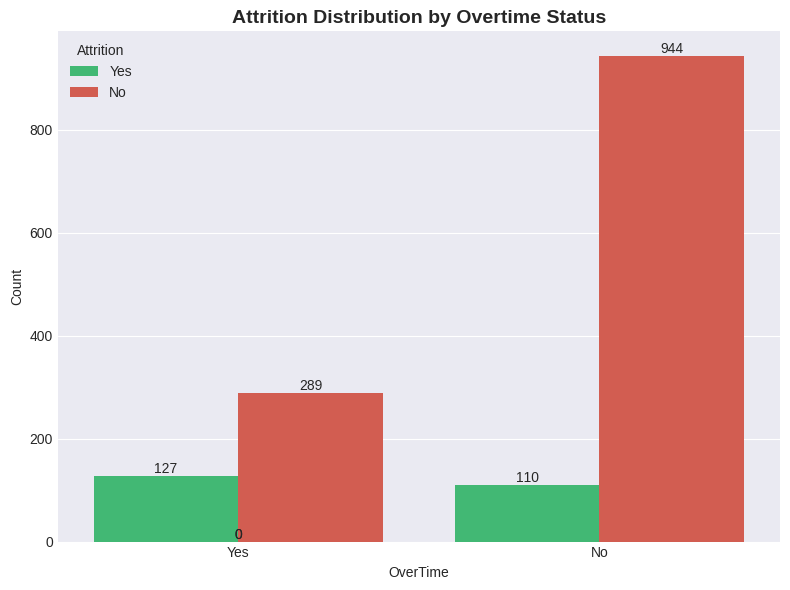

In [13]:
# Overtime Impact on Attrition
overtime_attrition = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack() * 100
overtime_attrition['Yes'] = overtime_attrition['Yes'].fillna(0)

print("Overtime Impact on Attrition")
print(f"Employees with Overtime - Attrition Rate: {overtime_attrition.loc['Yes', 'Yes']:.2f}%")
print(f"Employees without Overtime - Attrition Rate: {overtime_attrition.loc['No', 'Yes']:.2f}%")

# Visualization
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='OverTime', hue='Attrition', palette=['#2ecc71', '#e74c3c'])
plt.title('Attrition Distribution by Overtime Status', fontsize=14, fontweight='bold')
plt.xlabel('OverTime')
plt.ylabel('Count')
plt.legend(title='Attrition')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

Percent Salary Hike Impact on Attrition
Salary Hike Statistics by Attrition Status:
                mean  median       std
Attrition                             
No         15.231144    14.0  3.639511
Yes        15.097046    14.0  3.770294


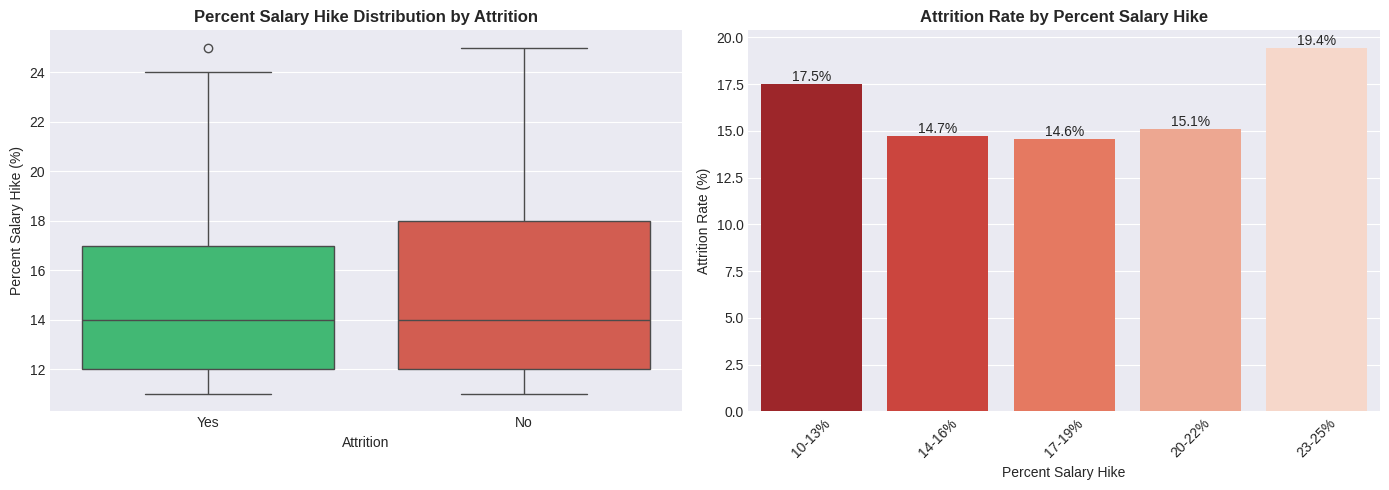

In [14]:
# Percent Salary Hike Analysis
print("Percent Salary Hike Impact on Attrition")
salary_hike_stats = df.groupby('Attrition')['PercentSalaryHike'].agg(['mean', 'median', 'std'])
print("Salary Hike Statistics by Attrition Status:")
print(salary_hike_stats)

# Create salary hike groups
df['SalaryHikeGroup'] = pd.cut(df['PercentSalaryHike'], bins=[10, 13, 16, 19, 22, 26], 
                                labels=['10-13%', '14-16%', '17-19%', '20-22%', '23-25%'])

hike_attrition = df.groupby('SalaryHikeGroup', observed=True)['Attrition'].value_counts(normalize=True).unstack() * 100
hike_attrition['Yes'] = hike_attrition['Yes'].fillna(0)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of salary hikes
sns.boxplot(data=df, x='Attrition', y='PercentSalaryHike', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Percent Salary Hike Distribution by Attrition', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Percent Salary Hike (%)')

# Plot 2: Attrition rate by salary hike group
ax = sns.barplot(x=hike_attrition.index, y=hike_attrition['Yes'], ax=axes[1], palette='Reds_r')
for i, p in enumerate(ax.patches):
    ax.annotate(f'{hike_attrition["Yes"].iloc[i]:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
axes[1].set_title('Attrition Rate by Percent Salary Hike', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Percent Salary Hike')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Stock Option Level Impact on Attrition
StockOption
Level 1     9.395973
Level 2     7.594937
Level 3    17.647059
None       24.405705
Name: Yes, dtype: float64


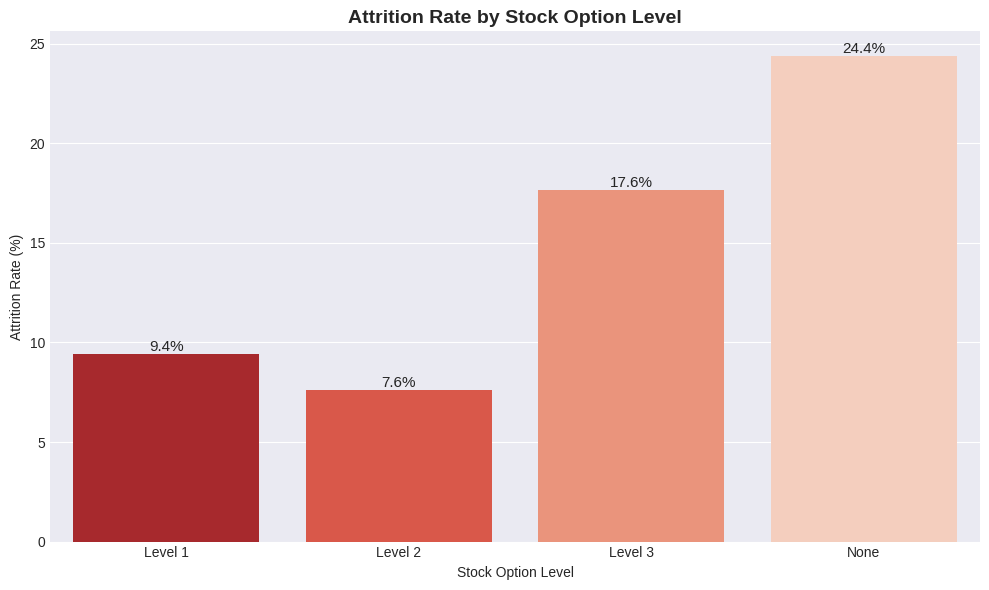

In [15]:
# Stock Option Level Analysis
stock_map = {0: 'None', 1: 'Level 1', 2: 'Level 2', 3: 'Level 3'}
df['StockOption'] = df['StockOptionLevel'].map(stock_map)

stock_attrition = df.groupby('StockOption', observed=True)['Attrition'].value_counts(normalize=True).unstack() * 100
stock_attrition['Yes'] = stock_attrition['Yes'].fillna(0)

print("Stock Option Level Impact on Attrition")
print(stock_attrition['Yes'])

# Visualization
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=stock_attrition.index, y=stock_attrition['Yes'], palette='Reds_r')
for i, p in enumerate(ax.patches):
    ax.annotate(f'{stock_attrition["Yes"].iloc[i]:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Attrition Rate by Stock Option Level', fontsize=14, fontweight='bold')
plt.xlabel('Stock Option Level')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

Environment Satisfaction Impact
EnvSatisfactionLevel
High         13.686534
Low          25.352113
Medium       14.982578
Very High    13.452915
Name: Yes, dtype: float64

Job Involvement Impact
JobInvolvementLevel
High         14.400922
Low          33.734940
Medium       18.933333
Very High     9.027778
Name: Yes, dtype: float64


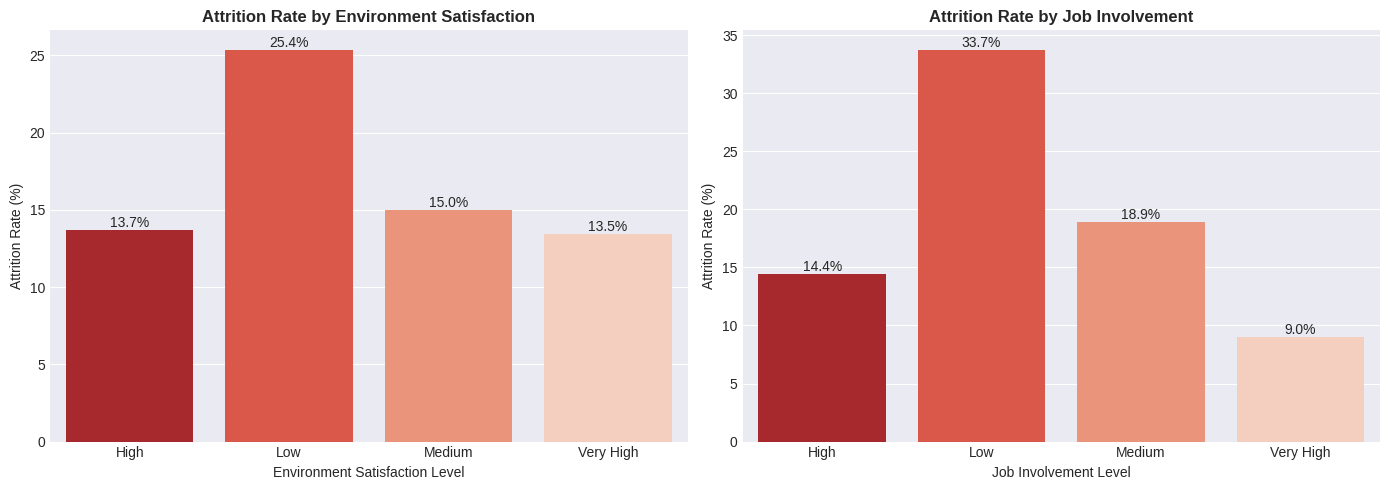

In [16]:
# Environment Satisfaction and Job Involvement Analysis
env_map = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}
jobinv_map = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}

df['EnvSatisfactionLevel'] = df['EnvironmentSatisfaction'].map(env_map)
df['JobInvolvementLevel'] = df['JobInvolvement'].map(jobinv_map)

# Environment Satisfaction
env_attrition = df.groupby('EnvSatisfactionLevel', observed=True)['Attrition'].value_counts(normalize=True).unstack() * 100
env_attrition['Yes'] = env_attrition['Yes'].fillna(0)

# Job Involvement
jobinv_attrition = df.groupby('JobInvolvementLevel', observed=True)['Attrition'].value_counts(normalize=True).unstack() * 100
jobinv_attrition['Yes'] = jobinv_attrition['Yes'].fillna(0)

print("Environment Satisfaction Impact")
print(env_attrition['Yes'])
print("\nJob Involvement Impact")
print(jobinv_attrition['Yes'])

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Environment Satisfaction
ax = sns.barplot(x=env_attrition.index, y=env_attrition['Yes'], ax=axes[0], palette='Reds_r')
for i, p in enumerate(ax.patches):
    ax.annotate(f'{env_attrition["Yes"].iloc[i]:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
axes[0].set_title('Attrition Rate by Environment Satisfaction', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Environment Satisfaction Level')
axes[0].set_ylabel('Attrition Rate (%)')

# Plot 2: Job Involvement
ax = sns.barplot(x=jobinv_attrition.index, y=jobinv_attrition['Yes'], ax=axes[1], palette='Reds_r')
for i, p in enumerate(ax.patches):
    ax.annotate(f'{jobinv_attrition["Yes"].iloc[i]:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
axes[1].set_title('Attrition Rate by Job Involvement', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Job Involvement Level')
axes[1].set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.show()

Distance From Home Analysis

Attrition Rate by Distance Group and Job Role
JobRole        Healthcare Representative  Human Resources  \
DistanceGroup                                               
0-5 miles                            2.0              8.0   
6-15 miles                           6.4             25.0   
16-30 miles                         15.2             54.5   

JobRole        Laboratory Technician  Manager  Manufacturing Director  \
DistanceGroup                                                           
0-5 miles                       22.3      5.2                     6.3   
6-15 miles                      26.3      4.0                     9.3   
16-30 miles                     23.0      5.3                     5.1   

JobRole        Research Director  Research Scientist  Sales Executive  \
DistanceGroup                                                           
0-5 miles                    2.9                16.0             13.0   
6-15 miles                   2.9  

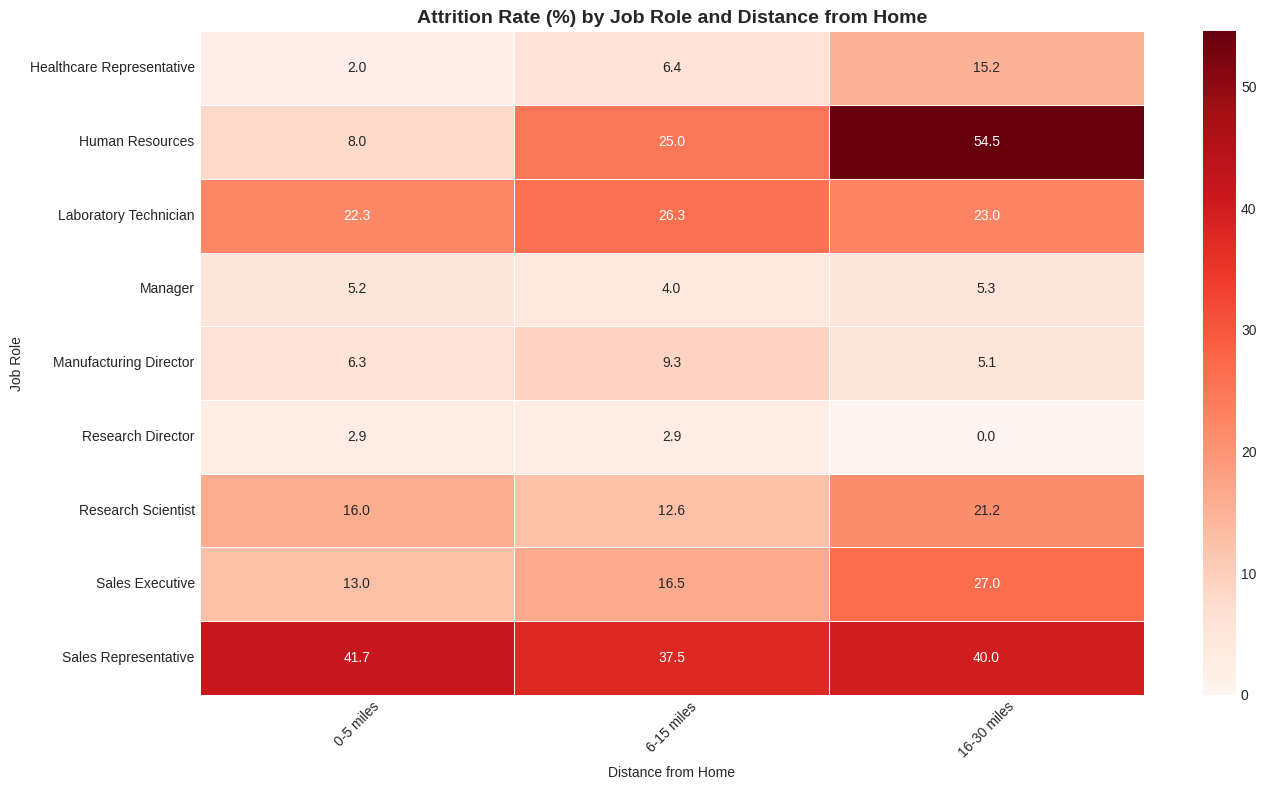

In [17]:
# Distance From Home by Job Role and Attrition
print("Distance From Home Analysis")


# Create distance groups
df['DistanceGroup'] = pd.cut(df['DistanceFromHome'], bins=[0, 5, 15, 30], 
                              labels=['0-5 miles', '6-15 miles', '16-30 miles'])

distance_job_attrition = df.groupby(['JobRole', 'DistanceGroup', 'Attrition'], observed=True).size().unstack(fill_value=0)
distance_job_attrition['Total'] = distance_job_attrition.sum(axis=1)
distance_job_attrition['Attrition_Rate'] = (distance_job_attrition['Yes'] / distance_job_attrition['Total'] * 100).fillna(0)

# Pivot for better view
distance_pivot = distance_job_attrition['Attrition_Rate'].unstack(level=0)
print("\nAttrition Rate by Distance Group and Job Role")
print(distance_pivot.round(1))

# Visualization
plt.figure(figsize=(14, 8))
distance_heatmap = df.groupby(['JobRole', 'DistanceGroup'], observed=True)['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100).unstack()

sns.heatmap(distance_heatmap, annot=True, fmt='.1f', cmap='Reds', linewidths=0.5)
plt.title('Attrition Rate (%) by Job Role and Distance from Home', fontsize=14, fontweight='bold')
plt.xlabel('Distance from Home')
plt.ylabel('Job Role')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

CORRELATION ANALYSIS: Key Factors vs Attrition

Top Factors Correlated with Attrition:
Attrition_Numeric     1.000000
DistanceFromHome      0.077924
NumCompaniesWorked    0.043494
MonthlyRate           0.015170
PerformanceRating     0.002889
                        ...   
Age                  -0.159205
MonthlyIncome        -0.159840
YearsInCurrentRole   -0.160545
JobLevel             -0.169105
TotalWorkingYears    -0.171063
Name: Attrition_Numeric, Length: 24, dtype: float64


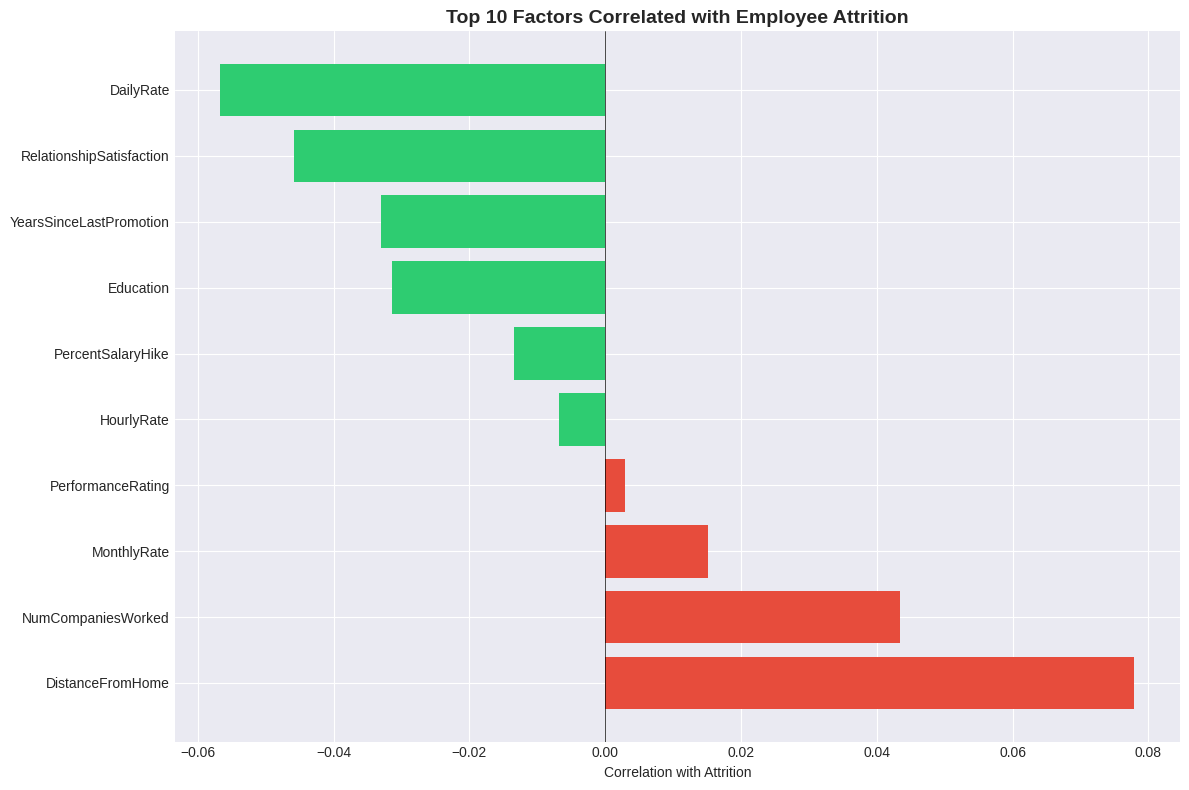

In [18]:
# Correlation Analysis of All Factors
print("CORRELATION ANALYSIS: Key Factors vs Attrition")

# Convert Attrition to numeric for correlation
df_numeric = df.copy()
df_numeric['Attrition_Numeric'] = (df_numeric['Attrition'] == 'Yes').astype(int)

# Select numeric columns for correlation
numeric_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
                'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
                'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating',
                'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',
                'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
                'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
                'Attrition_Numeric']

correlation_matrix = df_numeric[numeric_cols].corr()

# Get correlation with Attrition
attrition_corr = correlation_matrix['Attrition_Numeric'].sort_values(ascending=False)
print("\nTop Factors Correlated with Attrition:")
print(attrition_corr)

# Visualization
plt.figure(figsize=(12, 8))
top_factors = attrition_corr[1:11]  # Exclude Attrition itself
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_factors.values]
plt.barh(range(len(top_factors)), top_factors.values, color=colors)
plt.yticks(range(len(top_factors)), top_factors.index)
plt.xlabel('Correlation with Attrition')
plt.title('Top 10 Factors Correlated with Employee Attrition', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

In [19]:
# Summary Dashboard - All Key Metrics
print("SUMMARY DASHBOARD: KEY ATTRITION INSIGHTS")

# Create summary dataframe
summary_data = {
    'Metric': ['Overall Attrition Rate', 'Highest Attrition Age Group', 'Highest Attrition Gender',
               'Highest Attrition Department', 'Highest Attrition Job Role', 
               'Lowest Average Monthly Income (Attrition)', 'Highest Overtime Impact',
               'Lowest Job Satisfaction Impact', 'Lowest Work-Life Balance Impact'],
    'Value': [
        f"{attrition_percent['Yes']:.2f}%",
        age_attrition['Yes'].idxmax(),
        gender_attrition['Yes'].idxmax(),
        dept_attrition['Yes'].idxmax(),
        job_attrition['Yes'].idxmax(),
        f"${income_stats.loc['Yes', 'mean']:,.0f}",
        f"{overtime_attrition.loc['Yes', 'Yes']:.1f}% vs {overtime_attrition.loc['No', 'Yes']:.1f}%",
        f"{sat_attrition.loc['Low', 'Yes']:.1f}% (Low) vs {sat_attrition.loc['Very High', 'Yes']:.1f}% (Very High)",
        f"{wlb_attrition.loc['Bad', 'Yes']:.1f}% (Bad) vs {wlb_attrition.loc['Best', 'Yes']:.1f}% (Best)"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


SUMMARY DASHBOARD: KEY ATTRITION INSIGHTS
                                   Metric                            Value
                   Overall Attrition Rate                           16.12%
              Highest Attrition Age Group                            18-25
                 Highest Attrition Gender                             Male
             Highest Attrition Department                            Sales
               Highest Attrition Job Role             Sales Representative
Lowest Average Monthly Income (Attrition)                           $4,787
                  Highest Overtime Impact                   30.5% vs 10.4%
           Lowest Job Satisfaction Impact 22.8% (Low) vs 11.3% (Very High)
          Lowest Work-Life Balance Impact      31.2% (Bad) vs 17.6% (Best)


In [20]:
# ML - Data Preparation and Preprocessing
print("ML EMPLOYEE ATTRITION PREDICTION")
# Import libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

import warnings
warnings.filterwarnings('ignore')

# Prepare features
print("\nData Preparation")

df_ml = df.copy()

# Define target variable
target = 'Attrition'

# List of categorical columns to encode
categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 
                    'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

# Remove AgeGroup and other derived columns if they exist
derived_cols = ['AgeGroup', 'EducationLevel', 'JobSatisfactionLevel', 
                'WorkLifeBalanceLevel', 'SalaryHikeGroup', 'StockOption', 
                'EnvSatisfactionLevel', 'JobInvolvementLevel', 'DistanceGroup']
df_ml = df_ml.drop(columns=[col for col in derived_cols if col in df_ml.columns])

# Label encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le

# Encode target variable
le_target = LabelEncoder()
df_ml['Attrition'] = le_target.fit_transform(df_ml['Attrition'])

print(f"Target distribution: 0 (Stayed): {(df_ml['Attrition'] == 0).sum()}, 1 (Left): {(df_ml['Attrition'] == 1).sum()}")

# Separate features and target
X = df_ml.drop(columns=[target])
y = df_ml[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Scale numerical features
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


ML EMPLOYEE ATTRITION PREDICTION

Data Preparation
Target distribution: 0 (Stayed): 1233, 1 (Left): 237

Training set size: (1176, 34)
Test set size: (294, 34)


Feature Importance Analysis 

Top 15 Most Important Features for Predicting Attrition:
                    Feature  Importance
17            MonthlyIncome    0.071365
0                       Age    0.063924
27        TotalWorkingYears    0.060061
2                 DailyRate    0.051142
11               HourlyRate    0.050359
18              MonthlyRate    0.047954
8            EmployeeNumber    0.043478
4          DistanceFromHome    0.043328
21                 OverTime    0.042244
30           YearsAtCompany    0.039755
33     YearsWithCurrManager    0.036900
19       NumCompaniesWorked    0.033739
22        PercentSalaryHike    0.032481
14                  JobRole    0.032089
9   EnvironmentSatisfaction    0.027346


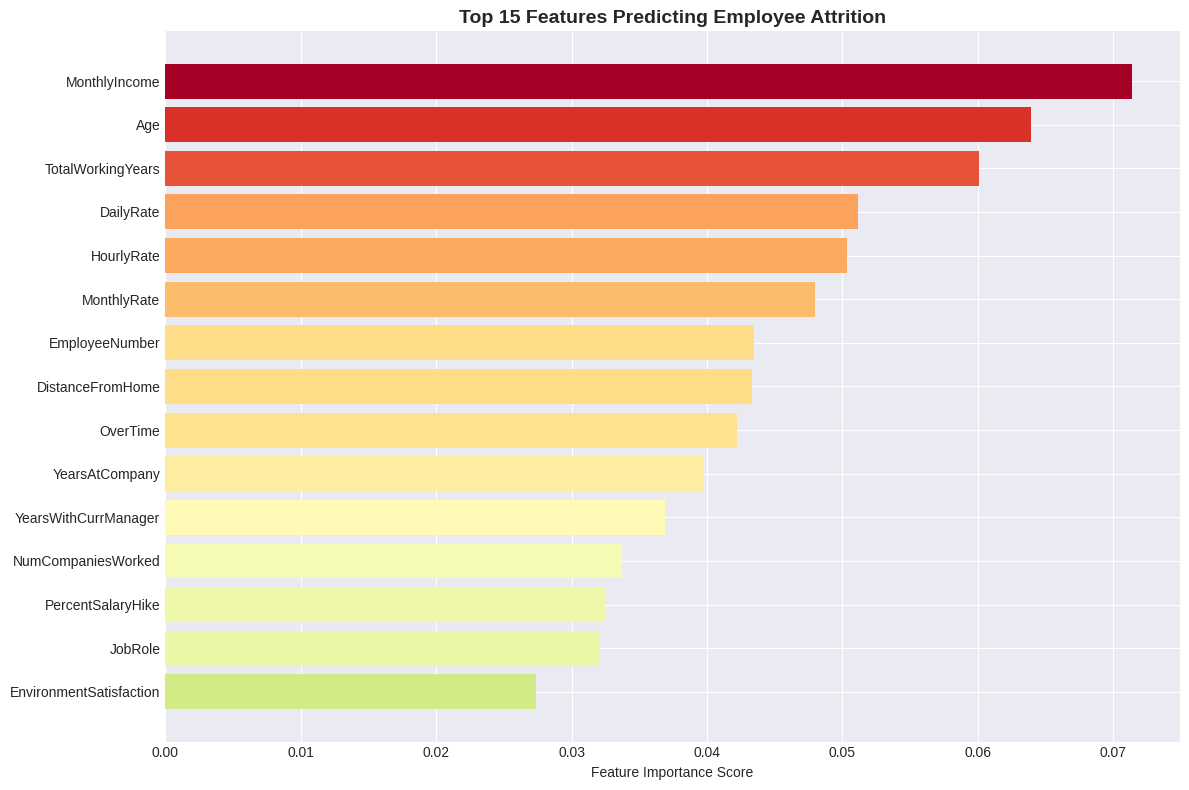

In [21]:
# Feature Importance Analysis
print("Feature Importance Analysis ")

# Use Random Forest to find feature importance
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X_train, y_train)

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features for Predicting Attrition:")
print(feature_importance.head(15))

# Visualization
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
colors = plt.cm.RdYlGn_r(top_features['Importance'].values / top_features['Importance'].max())
plt.barh(range(len(top_features)), top_features['Importance'].values, color=colors)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Features Predicting Employee Attrition', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
# Train Multiple ML Models and Compare
print("Training Multiple ML Models")

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, probability=True)
}

results = []
predictions = {}

print("\nModel Performance Comparison:")
print(f"{'Model':<20} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'ROC-AUC':<10}")


for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Calculate ROC-AUC if probability is available
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std()
    })
    
    predictions[name] = y_pred
    
    # Print results
    print(f"{name:<20} {accuracy:.4f}     {precision:.4f}     {recall:.4f}     {f1:.4f}     {roc_auc:.4f}" if roc_auc else f"{name:<20} {accuracy:.4f}     {precision:.4f}     {recall:.4f}     {f1:.4f}     N/A")

# Convert results to DataFrame
results_df = pd.DataFrame(results)


# Identify best model
best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model'] if results_df['ROC-AUC'].notna().any() else results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
print(f"\n Best Model: {best_model_name}")

Training Multiple ML Models

Model Performance Comparison:
Model                Accuracy   Precision  Recall     F1-Score   ROC-AUC   
Logistic Regression  0.8571     0.7778     0.1489     0.2500     0.7039
Decision Tree        0.8061     0.3750     0.3191     0.3448     0.5183
Random Forest        0.8299     0.3846     0.1064     0.1667     0.8038
Gradient Boosting    0.8469     0.5625     0.1915     0.2857     0.7964
SVM                  0.8401     0.0000     0.0000     0.0000     0.5023

 Best Model: Random Forest


In [23]:
# Hyperparameter Tuning for Random Forest 
print("Hyperparameter Tuning for Random Forest")

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)


print("Performing Grid Search (this may take a few minutes)...")
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                          cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Train best model
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_pred_proba_best = best_rf.predict_proba(X_test)[:, 1]

# Metrics for tuned model
print("\nTuned Random Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_best):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Stayed', 'Left']))

Hyperparameter Tuning for Random Forest
Performing Grid Search (this may take a few minutes)...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best Cross-Validation Score: 0.7926

Tuned Random Forest Performance:
Accuracy: 0.8299
Precision: 0.3333
Recall: 0.0638
F1-Score: 0.1071
ROC-AUC: 0.7803

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.98      0.91       247
        Left       0.33      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.59      0.52      0.51       294
weighted avg       0.76      0.83      0.78       294



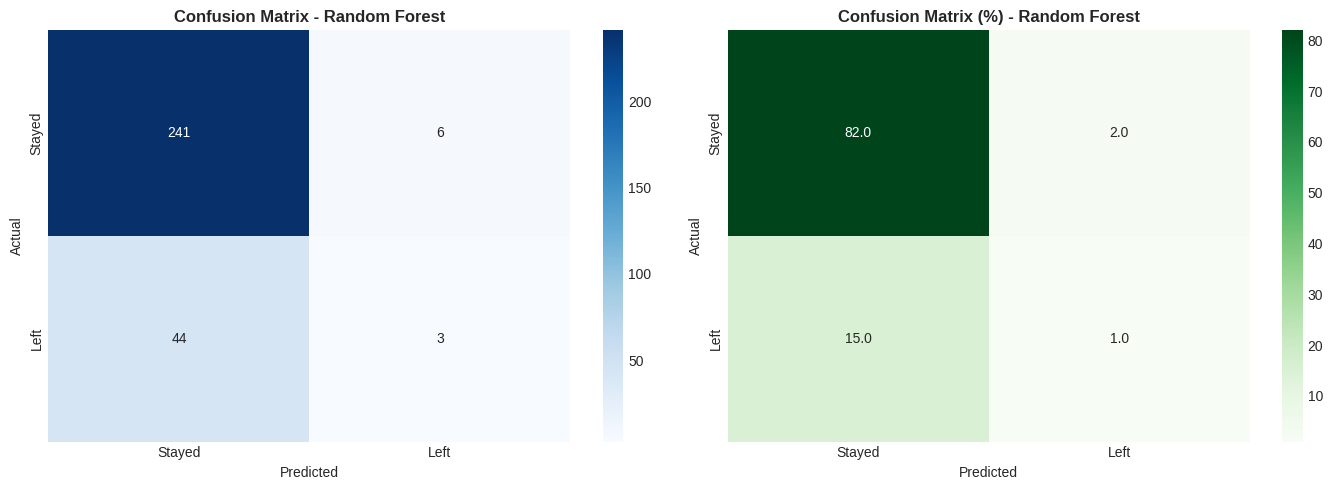


Confusion Matrix Interpretation
True Negatives (Correctly predicted Stayed): 241 (82.0%)
True Positives (Correctly predicted Left): 3 (1.0%)
False Positives (Wrongly predicted Left): 6 (2.0%)
False Negatives (Wrongly predicted Stayed): 44 (15.0%)


In [24]:
# Confusion Matrix for Best Model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix for Random Forest 
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
axes[0].set_title(f'Confusion Matrix - {best_model_name}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Calculate percentages for better interpretation
cm_percent = cm.astype('float') / cm.sum() * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens', ax=axes[1],
            xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
axes[1].set_title(f'Confusion Matrix (%) - {best_model_name}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Interpretation
print("\nConfusion Matrix Interpretation")
print(f"True Negatives (Correctly predicted Stayed): {cm[0,0]} ({cm_percent[0,0]:.1f}%)")
print(f"True Positives (Correctly predicted Left): {cm[1,1]} ({cm_percent[1,1]:.1f}%)")
print(f"False Positives (Wrongly predicted Left): {cm[0,1]} ({cm_percent[0,1]:.1f}%)")
print(f"False Negatives (Wrongly predicted Stayed): {cm[1,0]} ({cm_percent[1,0]:.1f}%)")

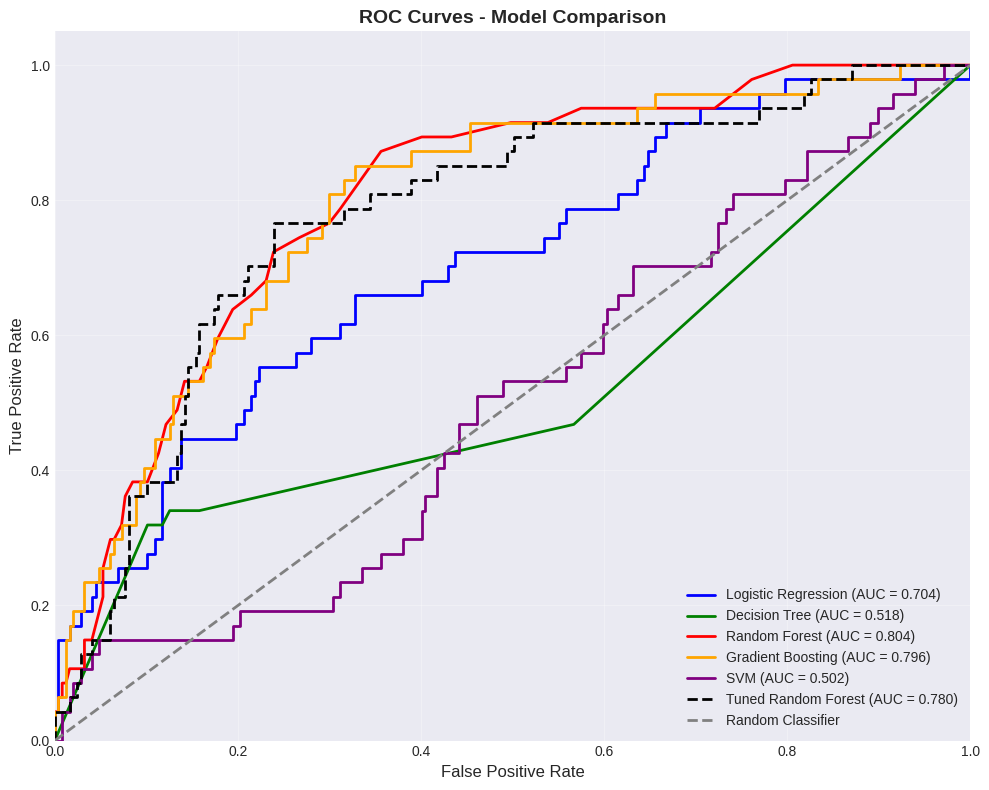

In [25]:
# ROC Curve for All Models
plt.figure(figsize=(10, 8))

colors = ['blue', 'green', 'red', 'orange', 'purple']
for (name, model), color in zip(models.items(), colors):
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Add ROC curve for tuned Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_best)
plt.plot(fpr_rf, tpr_rf, color='black', lw=2, linestyle='--', 
         label=f'Tuned Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_best):.3f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Feature Importance from Tuned Random Forest

Top 10 Most Important Features:
                 Feature  Importance
17         MonthlyIncome    0.077809
27     TotalWorkingYears    0.076851
0                    Age    0.071984
21              OverTime    0.065639
30        YearsAtCompany    0.049676
11            HourlyRate    0.043381
33  YearsWithCurrManager    0.043014
2              DailyRate    0.042813
18           MonthlyRate    0.040972
19    NumCompaniesWorked    0.040345


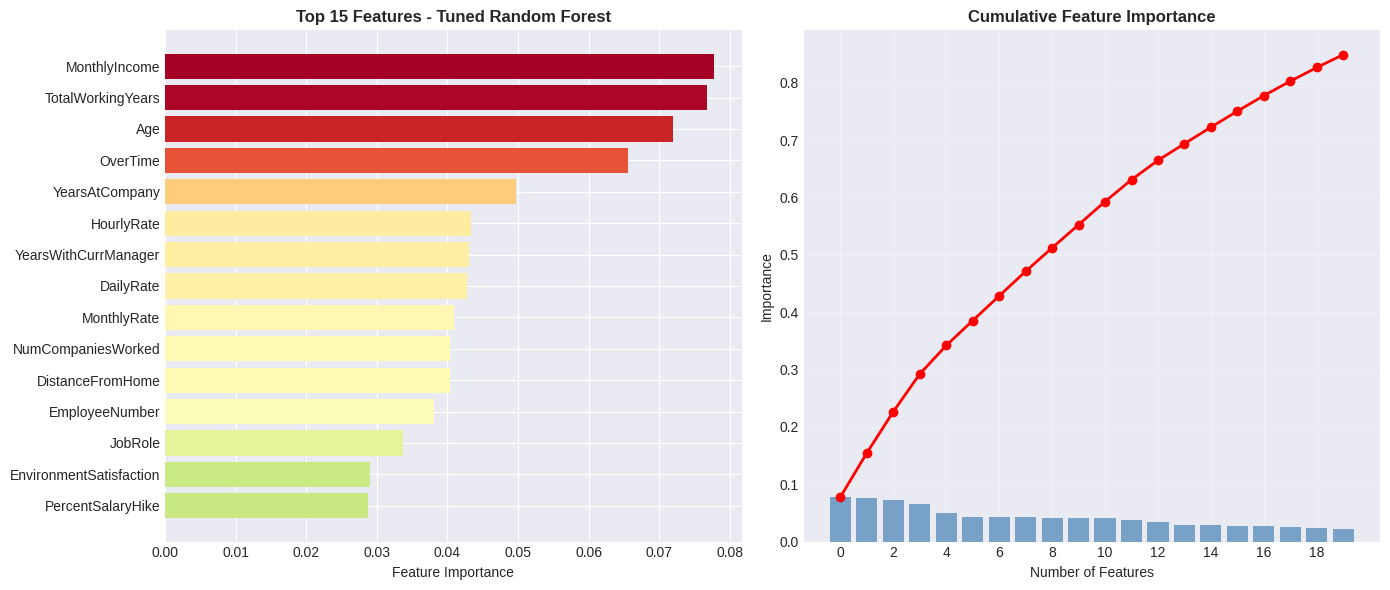


Key Insights from Feature Importance
Top 5 features account for 34.2% of predictive power
Top 10 features account for 55.2% of predictive power


In [26]:
# Feature Importance from Best Random Forest Model
print("Feature Importance from Tuned Random Forest")

# Get feature importance from best model
rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(rf_feature_importance.head(10))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Top 15 features
top_features = rf_feature_importance.head(15)
colors = plt.cm.RdYlGn_r(top_features['Importance'].values / top_features['Importance'].max())
axes[0].barh(range(len(top_features)), top_features['Importance'].values, color=colors)
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features['Feature'].values)
axes[0].set_xlabel('Feature Importance')
axes[0].set_title('Top 15 Features - Tuned Random Forest', fontweight='bold')
axes[0].invert_yaxis()

# Plot 2: Cumulative importance
rf_feature_importance['Cumulative'] = rf_feature_importance['Importance'].cumsum()
top_20 = rf_feature_importance.head(20)
axes[1].bar(range(len(top_20)), top_20['Importance'].values, color='steelblue', alpha=0.7)
axes[1].plot(range(len(top_20)), top_20['Cumulative'].values, 'ro-', linewidth=2, markersize=6)
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Importance')
axes[1].set_title('Cumulative Feature Importance', fontweight='bold')
axes[1].set_xticks(range(0, 20, 2))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key insights
print("\nKey Insights from Feature Importance")
print(f"Top 5 features account for {rf_feature_importance.head(5)['Importance'].sum()*100:.1f}% of predictive power")
print(f"Top 10 features account for {rf_feature_importance.head(10)['Importance'].sum()*100:.1f}% of predictive power")

In [27]:
# Make Predictions on New Data (Example)
print("Making Predictions on Sample Employees")

# Get feature names
feature_names = X.columns.tolist()

# Create sample employees for prediction
sample_employees = pd.DataFrame([
    {  # High risk employee
        'Age': 28, 'BusinessTravel': 2, 'DailyRate': 500, 'Department': 1,
        'DistanceFromHome': 20, 'Education': 2, 'EducationField': 1,
        'EmployeeCount': 1, 'EmployeeNumber': 9999, 'EnvironmentSatisfaction': 1,
        'Gender': 1, 'HourlyRate': 50, 'JobInvolvement': 1, 'JobLevel': 1,
        'JobRole': 5, 'JobSatisfaction': 1, 'MaritalStatus': 1,
        'MonthlyIncome': 3000, 'MonthlyRate': 10000, 'NumCompaniesWorked': 5,
        'Over18': 1, 'OverTime': 1, 'PercentSalaryHike': 10,
        'PerformanceRating': 3, 'RelationshipSatisfaction': 2,
        'StandardHours': 80, 'StockOptionLevel': 0, 'TotalWorkingYears': 5,
        'TrainingTimesLastYear': 2, 'WorkLifeBalance': 1,
        'YearsAtCompany': 1, 'YearsInCurrentRole': 1,
        'YearsSinceLastPromotion': 0, 'YearsWithCurrManager': 1
    },
    {  # Low risk employee
        'Age': 45, 'BusinessTravel': 0, 'DailyRate': 800, 'Department': 0,
        'DistanceFromHome': 5, 'Education': 4, 'EducationField': 2,
        'EmployeeCount': 1, 'EmployeeNumber': 9998, 'EnvironmentSatisfaction': 4,
        'Gender': 0, 'HourlyRate': 80, 'JobInvolvement': 4, 'JobLevel': 3,
        'JobRole': 1, 'JobSatisfaction': 4, 'MaritalStatus': 2,
        'MonthlyIncome': 12000, 'MonthlyRate': 15000, 'NumCompaniesWorked': 1,
        'Over18': 1, 'OverTime': 0, 'PercentSalaryHike': 20,
        'PerformanceRating': 4, 'RelationshipSatisfaction': 4,
        'StandardHours': 80, 'StockOptionLevel': 2, 'TotalWorkingYears': 15,
        'TrainingTimesLastYear': 4, 'WorkLifeBalance': 3,
        'YearsAtCompany': 10, 'YearsInCurrentRole': 5,
        'YearsSinceLastPromotion': 3, 'YearsWithCurrManager': 5
    }
])

# Ensure columns match
for col in feature_names:
    if col not in sample_employees.columns:
        sample_employees[col] = 0

sample_employees = sample_employees[feature_names]

# Make predictions
predictions_sample = best_rf.predict(sample_employees)
probabilities = best_rf.predict_proba(sample_employees)

print("\nSample Employee Predictions:")

for i in range(len(sample_employees)):
    risk = "HIGH RISK" if predictions_sample[i] == 1 else "LOW RISK"
    prob_left = probabilities[i][1] * 100
    prob_stay = probabilities[i][0] * 100
    print(f"\nEmployee {i+1}:")
    print(f"  Prediction: {risk}")
    print(f"  Probability of Leaving: {prob_left:.1f}%")
    print(f"  Probability of Staying: {prob_stay:.1f}%")
    
    if predictions_sample[i] == 1:
        print(f"   Recommended Action: Schedule retention interview, review compensation and work-life balance")
    else:
        print(f"  Recommended Action: Continue monitoring, good retention candidate")

Making Predictions on Sample Employees

Sample Employee Predictions:

Employee 1:
  Prediction: LOW RISK
  Probability of Leaving: 49.2%
  Probability of Staying: 50.8%
  Recommended Action: Continue monitoring, good retention candidate

Employee 2:
  Prediction: LOW RISK
  Probability of Leaving: 6.3%
  Probability of Staying: 93.7%
  Recommended Action: Continue monitoring, good retention candidate


Final Model Comparison Summary


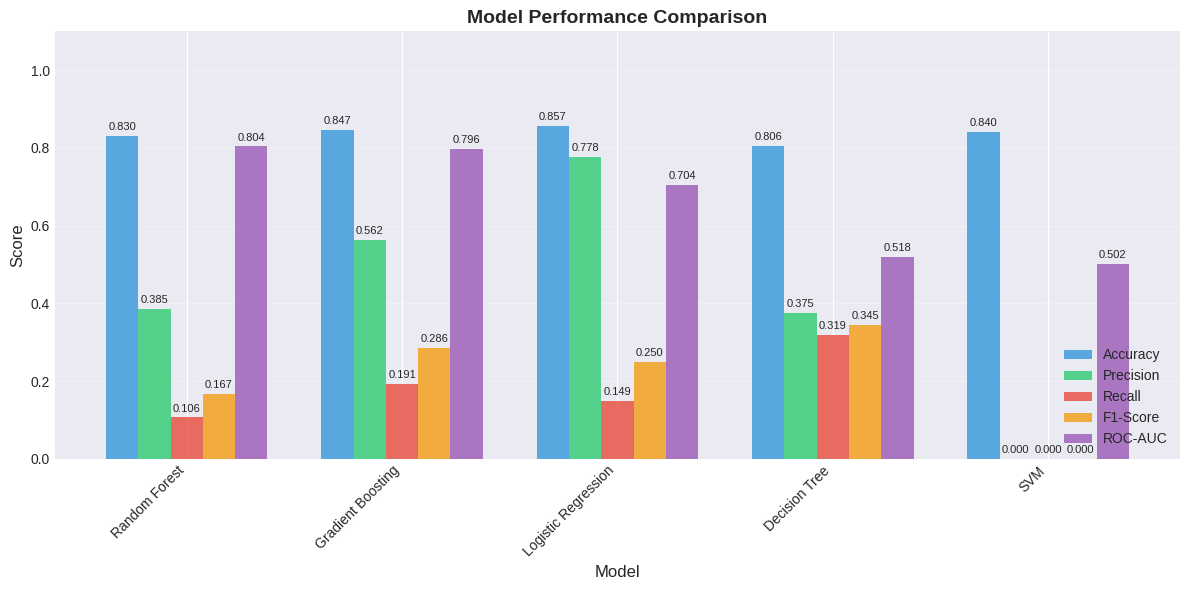


RECOMMENDATION:
The Random Forest model performs best with ROC-AUC = 0.8038
This model can be used to identify employees at risk of attrition for proactive retention strategies.


In [28]:
# Model Comparison Summary Visualization
print("Final Model Comparison Summary")

# Create comparison dataframe
comparison_df = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].copy()
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Create grouped bar chart
x = np.arange(len(comparison_df))
width = 0.15
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = comparison_df[metric].values
    bars = ax.bar(x + i*width, values, width, label=metric, color=color, alpha=0.8)
    
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        if not pd.isna(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nRECOMMENDATION:")
print(f"The {best_model_name} model performs best with ROC-AUC = {results_df.loc[results_df['Model'] == best_model_name, 'ROC-AUC'].values[0]:.4f}")
print("This model can be used to identify employees at risk of attrition for proactive retention strategies.")